## Build a decision tree

**Introduction**
In this activity, you’ll build a decision tree model that makes predictions for a target based on multiple features. Because decision trees are used across a wide array of industries, becoming proficient in the process of building one will help you expand your skill set in a widely-applicable way.

For this activity, you work as a consultant for an airline. The airline is interested in predicting whether a future customer would be satisfied with their services given previous customer feedback about their flight experience. The airline would like you to construct and evaluate a model that can accomplish this goal. Specifically, they are interested in knowing which features are most important to customer satisfaction.

The data for this activity includes survey responses from 129,880 customers. It includes data points such as class, flight distance, and in-flight entertainment, among others. In a previous activity, you utilized a binomial logistic regression model to help the airline better understand this data. In this activity, your goal will be to utilize a decision tree model to predict whether or not a customer will be satisfied with their flight experience.

Because this activity uses a dataset from the industry, you will need to conduct basic EDA, data cleaning, and other manipulations to prepare the data for modeling.

In this activity, you’ll practice the following skills:

1. Importing packages and loading data
2. Exploring the data and completing the cleaning process
3. Building a decision tree model
4. Tuning hyperparameters using GridSearchCV
5. Evaluating a decision tree model using a confusion matrix and various other plots

Import relevant Python packages. Use DecisionTreeClassifier, plot_tree, and various imports from sklearn.metrics to build, visualize, and evaluate the model.

In [3]:
# Standard operational package imports
import numpy as np
import pandas as pd

# Important imports for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import sklearn.metrics as metrics

# Visualization package imports
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Load the dataset
df_original = pd.read_csv('Invistico_Airline.csv')
df_original.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65.0,Personal Travel,Eco,265.0,0,0.0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47.0,Personal Travel,Business,NaN,0,0.0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15.0,Personal Travel,Eco,2138.0,0,0.0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60.0,Personal Travel,Eco,623.0,0,0.0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,99.0,Personal Travel,NaN,354.0,0,0.0,0,...,4,2,2,0,2,4,2,5,0,0.0


**Data exploration, data cleaning, and model preparation**
**Prepare the data**
After loading the dataset, prepare the data to be suitable for decision tree classifiers. This includes:

1. Exploring the data
2. Checking for missing values
3. Encoding the data
4. Renaming a column
5. Creating the training and testing data

In [5]:
#Explore the data
df_original.dtypes

satisfaction                          object
Gender                                object
Customer Type                         object
Age                                  float64
Type of Travel                        object
Class                                 object
Flight Distance                      float64
Seat comfort                           int64
Departure/Arrival time convenient    float64
Food and drink                         int64
Gate location                        float64
Inflight wifi service                float64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival De

**Output unique values**
The Class column is ordinal (meaning there is an inherent order that is significant). For example, airlines typically charge more for 'Business' than 'Eco Plus' and 'Eco'. Output the unique values in the Class column.

In [6]:
df_original['Class'].unique()

array(['Eco', 'Business', nan, 'Eco Plus'], dtype=object)

**Check the counts of the predicted labels**
In order to predict customer satisfaction, verify if the dataset is imbalanced. To do this, check the counts of each of the predicted labels.

In [7]:
df_original['satisfaction'].value_counts()

satisfied       71087
dissatisfied    58793
Name: satisfaction, dtype: int64

**Question: How many satisfied and dissatisfied customers were there?**

There are 71087 satisfied customers and 58793 dissatisfied customers.

**Question: What percentage of customers were satisfied?**

54.7 percent (71087/129880) of customers were satisfied. This value can be compared to a decision tree's model accuracy.

**Check for missing values**
The sklearn decision tree implementation does not support missing values. Check for missing values in the rows of the data.

In [8]:
df_original.isnull().sum()

satisfaction                           0
Gender                                 0
Customer Type                         17
Age                                   16
Type of Travel                        17
Class                                 17
Flight Distance                       19
Seat comfort                           0
Departure/Arrival time convenient      4
Food and drink                         0
Gate location                          5
Inflight wifi service                  4
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

**Question: Why is it important to check how many rows and columns there are in the dataset?**

This is important to check because if there are only a small number of missing values in the dataset, they can more safely be removed.

In [9]:
#Check the number of rows and columns in the dataset
df_original.shape

(129880, 23)

In [10]:
#Drop the rows with missing values
df_subset  = df_original.dropna(axis=0).reset_index(drop = True)

**Check that df_subset does not contain any missing values.**

In [11]:
df_subset.isna().sum()

satisfaction                         0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

**Check the number of rows and columns in the dataset again**

In [12]:
df_subset.shape

(129462, 23)

**Encode the data**
Five columns (satisfaction, Customer Type, Type of Travel, Class and Gender) are the pandas dtype object. Decision trees need numeric columns. Start by converting the ordinal Class column into numeric.

In [13]:
#Use the map() or replace() function.
df_subset['Class'] = df_subset['Class'].map({'Business' : 3, 'Eco Plus':2, 'Eco': 1})

To represent the data in the target variable numerically, assign "satisfied" to the label 1 and "dissatisfied" to the label 0 in the satisfaction column.

In [14]:
df_subset['satisfaction'] = df_subset['satisfaction'].replace({'satisfied' : 1, 'dissatisfied': 0})

**Convert categorical columns into numeric**
There are other columns in the dataset that are still categorical. Be sure to convert categorical columns in the dataset into numeric.

In [15]:
df_subset = pd.get_dummies(df_subset, drop_first = True)

In [16]:
#Check column data types
df_subset.dtypes

satisfaction                           int64
Age                                  float64
Class                                  int64
Flight Distance                      float64
Seat comfort                           int64
Departure/Arrival time convenient    float64
Food and drink                         int64
Gate location                        float64
Inflight wifi service                float64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Gender_Male                            uint8
Customer Type_disloyal Customer        uint8
Type of Tr

**Create the training and testing data**
Put 75% of the data into a training set and the remaining 25% into a testing set.

In [18]:
y = df_subset["satisfaction"]

X = df_subset.copy()
X = X.drop('satisfaction', axis = 1)
           
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=0)

**Model building**
Fit a decision tree classifier model to the data
Make a decision tree instance called decision_tree and pass in 0 to the random_state parameter.  Fit the model on the training set, use the predict() function on the testing set, and assign those predictions to the variable dt_pred.

In [21]:
decision_tree = DecisionTreeClassifier(random_state=0)
decision_tree.fit(X_train,y_train)
y_pred = decision_tree.predict(X_test)

**Question: What are some advantages of using decision trees versus other models you have learned about?**

Decision trees require no assumptions regarding the distribution of underlying data and don't require scaling of features. This lab uses decision trees because there is no need for additional data processing, unlike some other models.

In [23]:
#print evaluation metrics
print('Accuracy:', '%.6f' % metrics.accuracy_score(y_test,y_pred))
print('Precision:', '%.6f' % metrics.precision_score(y_test,y_pred))
print('Recall:', '%.6f' % metrics.recall_score(y_test,y_pred))
print('F1 Score:', '%.6f' % metrics.f1_score(y_test,y_pred))

Accuracy: 0.940431
Precision: 0.943190
Recall: 0.948504
F1 Score: 0.945840


**Question: Are there any additional steps you could take to improve the performance or function of your decision tree?**

Decision trees can be particularly susceptible to overfitting. Combining hyperparameter tuning and grid search can help ensure this doesn't happen. For instance, setting an appropriate value for max depth could potentially help reduce a decision tree's overfitting problem by limiting how deep a tree can grow.

## Produce a confusion matrix

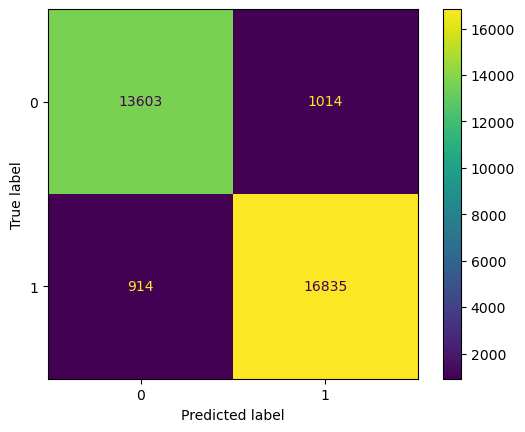

In [24]:
# Construct and display your confusion matrix.
cm = metrics.confusion_matrix(y_test, y_pred)
viz = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = decision_tree.classes_)
viz.plot()

**Question: What patterns can you identify between true positives and true negatives, as well as false positives and false negatives?**

In the confusion matrix, there are a high proportion of true positives and true negatives (where the matrix accurately predicted that the customer would be satisfied or dissatified, respectively).

The matrix also had a relatively low number of false positives and false negatives (where the matrix innacurately predicted that the customer would be satisfied or dissatified, respectively.)

**Plot the decision tree**
Examine the decision tree. Use plot_tree function to produce a visual representation of the tree to pinpoint where the splits in the data are occurring.

In [28]:
list(X.columns)

['Age',
 'Class',
 'Flight Distance',
 'Seat comfort',
 'Departure/Arrival time convenient',
 'Food and drink',
 'Gate location',
 'Inflight wifi service',
 'Inflight entertainment',
 'Online support',
 'Ease of Online booking',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Cleanliness',
 'Online boarding',
 'Departure Delay in Minutes',
 'Arrival Delay in Minutes',
 'Gender_Male',
 'Customer Type_disloyal Customer',
 'Type of Travel_Personal Travel']

[Text(0.5, 0.9, 'Inflight entertainment <= 3.5\ngini = 0.496\nsamples = 97096\nvalue = [43988, 53108]'),
 Text(0.25, 0.7, 'Seat comfort <= 3.5\ngini = 0.338\nsamples = 43550\nvalue = [34187, 9363]'),
 Text(0.125, 0.5, 'Seat comfort <= 0.5\ngini = 0.246\nsamples = 38133\nvalue = [32650, 5483]'),
 Text(0.0625, 0.3, 'Ease of Online booking <= 0.5\ngini = 0.006\nsamples = 1947\nvalue = [6, 1941]'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'Class <= 2.5\ngini = 0.177\nsamples = 36186\nvalue = [32644, 3542]'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'Seat comfort <= 4.5\ngini = 0.406\nsamples = 5417\nvalue = [1537, 3880]'),
 Text(0.3125, 0.3, 'Gate location <= 3.5\ngini = 0.488\nsamples = 3567\nvalue = [1513, 2054]'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, '\n  (...)  \n'),
 Text(0.4375, 0.3, 'Age <= 76.5\ngini = 0.026\nsamples = 1850\nvalue = [24, 1826]'),
 Text(0.4

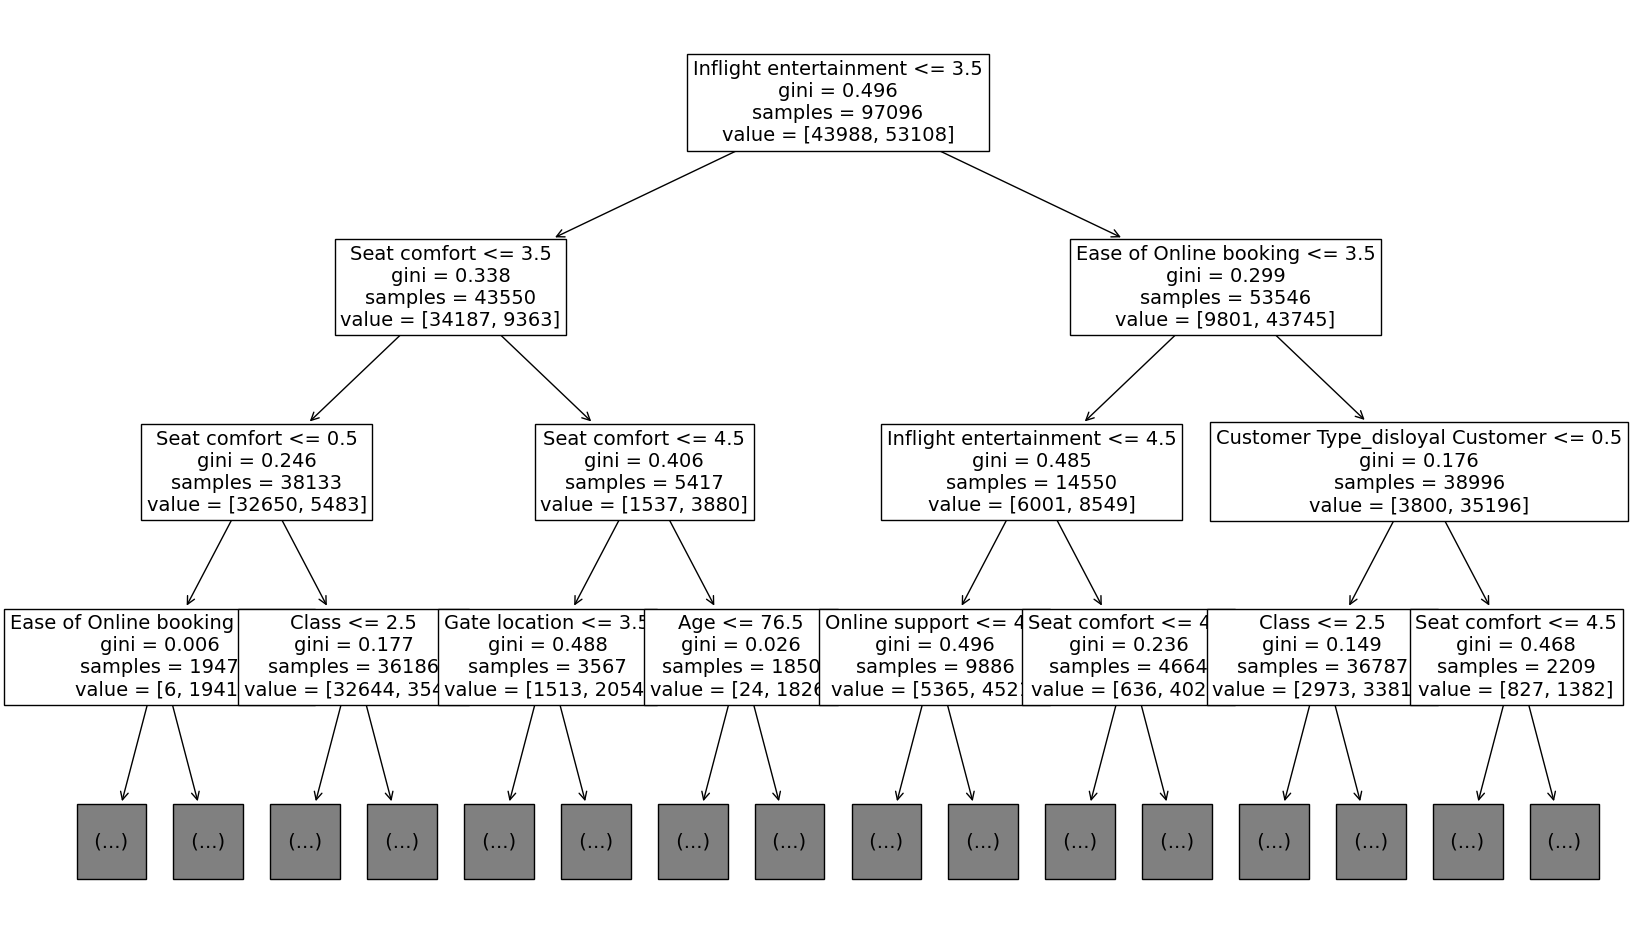

In [33]:
plt.figure(figsize=(20,12))
plot_tree(decision_tree, max_depth=3, fontsize=14, feature_names=list(X.columns))

 **Calculate feature importance**
The DecisionTreeClassifier class comes with a feature_importances_ attribute that provides access to the features' relative importance in the model. The feature importances are computed when the fit() method is called on the DecisionTreeClassifier instance. In other words, it's information that is generated during model training. Here's how it works.

For each feature used in the tree, the algorithm finds all of the decision nodes that use that particular feature as the split criterion. Then for each of those decision nodes it computes the decrease in Gini impurity (or entropy, or log loss, or whatever metric you select when you fit the model—default is Gini impurity) that results from that split (so, the decrease from parent to children). Then the algorithm sums up the decreases across all the decisions made using that feature and expresses it as a percentage of the total decrease that resulted from all features.

Using the feature_importances_ attribute to fetch the relative importances of each feature, you can then plot the results.

<Axes: >

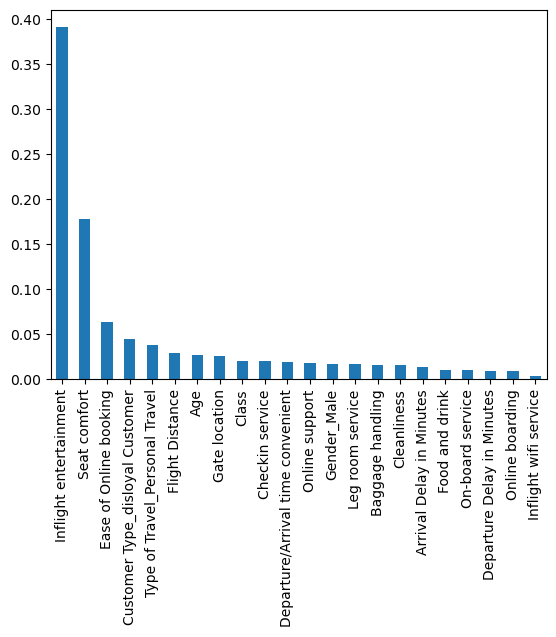

In [34]:
importances = decision_tree.feature_importances_
feature_importances = pd.Series(importances, index = X.columns).sort_values(ascending=False)
feature_importances.plot.bar()

The feature importance graph seems to confirm that 'Inflight entertainment', 'Seat comfort', and 'Ease of Online booking' are the most important features for this model.

**Hyperparameter tuning**
Knowing how and when to adjust or tune a model can help a data professional significantly increase performance. In this section, you will find the best values for the hyperparameters max_depth and min_samples_leaf using grid search and cross validation. Below are some values for the hyperparameters max_depth and min_samples_leaf.

In [40]:
tree_para = {'max_depth':[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,30,40,50],
             'min_samples_leaf': [2,3,4,5,6,7,8,9, 10, 15, 20, 50]}

scoring = { "accuracy": "accuracy", 
           "precision": "precision", 
           "recall": "recall", 
           "f1": "f1" }

**Check combinations of values**
Check every combination of values to examine which pair has the best evaluation metrics. Make a decision tree instance called tuned_decision_tree with random_state=0, make a GridSearchCV instance called clf, make sure to refit the estimator using "f1", and fit the model on the training set.

Note: This cell may take up to 15 minutes to run.

In [41]:
tuned_decision_tree = DecisionTreeClassifier(random_state=0)

#cv=5 — 5‑fold cross‑validation
#refit="f1" — choose the best model based on F1 score
clf = GridSearchCV(tuned_decision_tree,
                   tree_para,
                   scoring = scoring,
                   cv=5, 
                   refit="f1")
#fit the model
clf.fit(X_train, y_train)                                  

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13, 14, 15, 16, 17, 18, 19, 20, 30, 40,
                                       50],
                         'min_samples_leaf': [2, 3, 4, 5, 6, 7, 8, 9, 10, 15,
                                              20, 50]},
             refit='f1',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

**Question: How can you determine the best combination of values for the hyperparameters?**

Use the best estimator tool to help uncover the best pair combination.

In [45]:
clf.best_estimator_

DecisionTreeClassifier(max_depth=17, min_samples_leaf=3, random_state=0)

**Question: What is the best combination of values for the hyperparameters?**

After running the DecisionTreeClassifier, the maximum depth is 17 and the minimum number of samples is **three**, meaning this is the best combination of values.

In [43]:
#Determine the best average validation score
print("Best Avg. Validation Score: ", '%4f' % clf.best_score_)

Best Avg. Validation Score:  0.947552


In [46]:
#Compute the best combination of values for the hyperparameters
## Best model chosen by GridSearchCV (based on F1 because refit="f1")
best_model = clf.best_estimator_

# Predict on the test set 
y_pred = best_model.predict(X_test)

print('Accuracy:', '%.6f' % metrics.accuracy_score(y_test,y_pred))
print('Precision:', '%.6f' % metrics.precision_score(y_test,y_pred))
print('Recall:', '%.6f' % metrics.recall_score(y_test,y_pred))
print('F1 Score:', '%.6f' % metrics.f1_score(y_test,y_pred))

Accuracy: 0.945128
Precision: 0.954320
Recall: 0.945180
F1 Score: 0.949728


In [47]:
results = pd.DataFrame(columns=['Model', 'F1', 'Recall', 'Precision', 'Accuracy'])

def make_results(model_name, model_object):
    """
    Accepts as arguments a model name (your choice - string) and
    a fit GridSearchCV model object.

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean F1 score across all validation folds.  
    """

    # Get all the results from the CV and put them in a df.
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(mean f1 score).
    best_estimator_results = cv_results.iloc[cv_results['mean_test_f1'].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row.
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

 
    # Create table of results
    table = pd.DataFrame({'Model': [model_name],
                          'F1': [f1],
                          'Recall': [recall],
                          'Precision': [precision],
                          'Accuracy': [accuracy]
                         }
                        )

    return table

result_table = make_results("Tuned Decision Tree", clf)

result_table

,Model,F1,Recall,Precision,Accuracy
0,Tuned Decision Tree,0.947552,0.940103,0.955123,0.943077


**Question: Was the additional performance improvement from hyperparameter tuning worth the computational cost? Why or why not?**

The F1 score for the decision tree that was not hyperparameter tuned is 0.940940 and the F1 score for the hyperparameter-tuned decision tree is 0.947552. While ensuring that overfitting doesn't occur is necessary for some models, it didn't make a meaningful difference in improving this model.

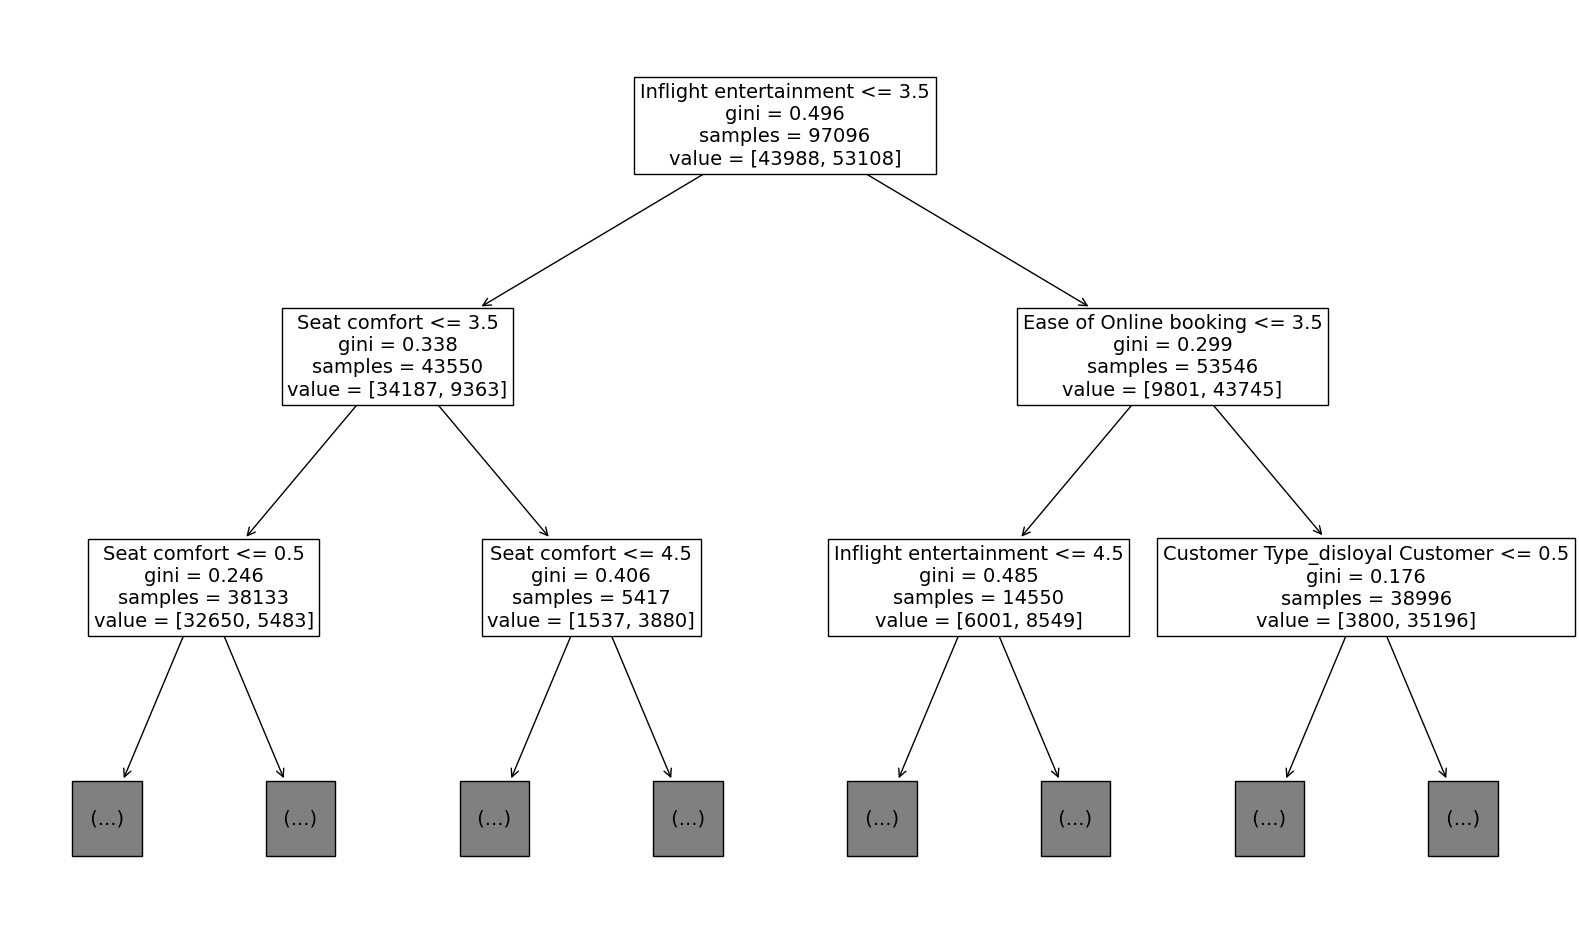

In [51]:
#Plot the "best" decision tree
plt.figure(figsize=(20,12))
plot_tree(clf.best_estimator_, max_depth=2, fontsize=14, feature_names=list(X.columns));

The plot makes it seem like 'Inflight entertainment', 'Seat comfort', and 'Ease of Online booking' are among the most important features. The code below outputs a "most important" features graph from the model.

**Build another feature importance graph**

<Axes: >

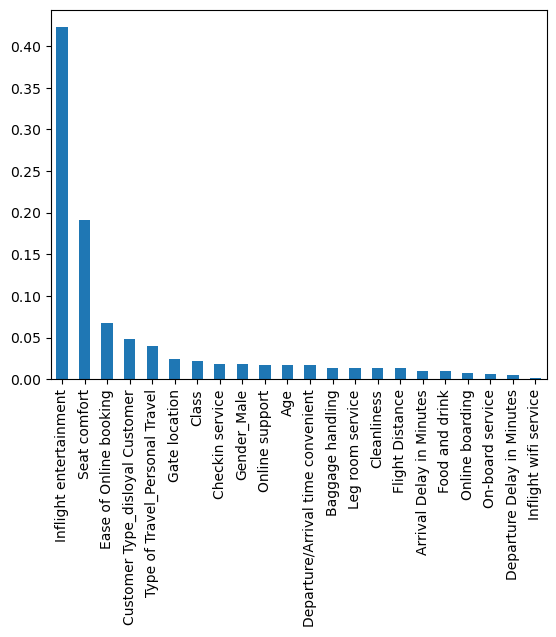

In [52]:
importances = clf.best_estimator_.feature_importances_

feature_importances = pd.Series(importances,index=X.columns).sort_values(ascending=False)
feature_importances.plot.bar()

The feature importance graph seems to confirm that 'Inflight entertainment', 'Seat comfort', and 'Ease of Online booking' are the "most important" features for this model.

**Question: What do you think is the most important metric in this business case?**

Any of the metrics in this business case could be considered important, depending on what the stakeholder or domain expert cares about. The following are reasons why each metric is important:

1. Accuracy tends to be the metric that the stakeholders can best understand.

2. Precision measures what proportion of predicted positives is truly positive. For example, if you wanted to not falsely claiming a customer is satisfied, precision would be a good metric. Assuming a customer is happy when they are really not might lead to customer churn.

3. Recall measures the percentage of actual positives a model correctly identified (true positive). For this dataset, the airline might want to limit false negatives (actually satisfied people who are predicted to be unsatisfied). Assuming a customer is unhappy when the customer is happy can lead to the airline wasting resources trying to improve the customer experience of an already happy customer.

4. F1 balances precision and recall. It is the harmonic mean of precision and recall, or their product divided by their sum.

**Considerations**
**What are some key takeaways that you learned from this lab?**

- Machine learning workflows may be used to clean and encode data for machine learning.
- While hyperparameter tuning can lead to an increase in performance, it doesn't always.
- The visualization of the decision tree as well as the feature graph can be used to determine which features are most important for a decision tree.
**What findings would you share with others?**

- Decision trees accurately predicted satisfaction over 94 percent of the time.
- The confusion matrix is useful as it shows a similar number of true positives and true negatives.
- The visualization of the decision tree and the feature importance graph both suggest that 'Inflight entertainment', 'Seat comfort', and 'Ease of Online booking' are the most important features in the model.
**What would you recommend to stakeholders?**

- Customer satisfaction is highly tied to 'Inflight entertainment', 'Seat comfort', and 'Ease of Online booking'. Improving these experiences should lead to better customer satisfaction.
- The success of the model suggests that the airline should invest more effort into model building and model understanding since this model semed to be very good at predicting customer satisfaction.